In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv('../data/processed/monstros_srd_ml_v2.csv')

features = [
    'armor_class', 'hit_points', 'dpr_maximo',
    'strength', 'dexterity', 'constitution', 'intelligence', 'wisdom', 'charisma',
    'save_dc_max', 'qtd_imunidades', 'qtd_resistencias', 'qtd_habilidades_especiais'
]
X = df[features]
y = df['cr']

# Separa os dados em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializa o modelo RandomForest com 100 árvores de decisão
modelo = RandomForestRegressor(n_estimators=100, random_state=42)

# Treina o modelo com os dados de treino
modelo.fit(X_train, y_train)

# Realiza as previsões com os dados de teste para avaliar a generalização
previsoes = modelo.predict(X_test)

# Avalia o desempenho matemático do modelo
erro_medio = mean_absolute_error(y_test, previsoes)
r2 = r2_score(y_test, previsoes)

print("DESEMPENHO DO MODELO (DADOS DE TESTE)")
print(f"Margem de Erro Média (MAE): {erro_medio:.2f} níveis de CR")
print(f"Acurácia Global (R²): {r2:.2f} (1.0 seria a perfeição)")

DESEMPENHO DO MODELO (DADOS DE TESTE)
Margem de Erro Média (MAE): 0.73 níveis de CR
Acurácia Global (R²): 0.95 (1.0 seria a perfeição)


In [2]:
# Pede para o modelo prever o CR matemático do livro inteiro
df['cr_matematico'] = modelo.predict(X)

# Calcula a discrepância (Erro de Balanceamento da Editora)
# Valores positivos altos = Monstro muito mais forte do que o CR diz
# Valores negativos baixos = Monstro muito mais fraco do que o CR diz
df['discrepancia'] = df['cr_matematico'] - df['cr']

# Arredonda as casas decimais para facilitar a leitura da tabela final
df['cr_matematico'] = df['cr_matematico'].round(1)
df['discrepancia'] = df['discrepancia'].round(1)

colunas_finais = ['name', 'cr', 'cr_matematico', 'discrepancia', 'hit_points', 'dpr_maximo']

print("TOP 10 MONSTROS FORTES (Mais fortes do que o CR oficial indica)")
assassinos = df.sort_values(by='discrepancia', ascending=False).head(10)
display(assassinos[colunas_finais])

print("\nTOP 10 MONSTROS FRACOS (Mais fracos do que o CR oficial indica)")
fracotes = df.sort_values(by='discrepancia', ascending=True).head(10)
display(fracotes[colunas_finais])

TOP 10 MONSTROS FORTES (Mais fortes do que o CR oficial indica)


,name,cr,cr_matematico,discrepancia,hit_points,dpr_maximo
151,Green Hag,3.0,7.6,4.6,82,13.0
84,Dragon Turtle,17.0,20.6,3.6,341,85.0
108,Gelatinous Cube,2.0,4.2,2.2,84,31.5
5,Adult Bronze Dragon,15.0,16.9,1.9,212,87.0
7,Adult Gold Dragon,17.0,18.8,1.8,256,88.5
204,Night Hag,5.0,6.6,1.6,112,13.0
70,Couatl,4.0,5.6,1.6,97,10.0
9,Adult Red Dragon,17.0,18.4,1.4,256,85.5
314,Young Bronze Dragon,8.0,9.3,1.3,142,55.0
190,Mammoth,6.0,7.2,1.2,126,29.0



TOP 10 MONSTROS FRACOS (Mais fracos do que o CR oficial indica)


,name,cr,cr_matematico,discrepancia,hit_points,dpr_maximo
60,Chain Devil,11.0,5.2,-5.8,85,36.0
183,Lich,21.0,17.6,-3.4,135,31.5
63,Clay Golem,9.0,5.8,-3.2,133,32.0
278,Tarrasque,30.0,26.9,-3.1,676,204.0
256,Solar,21.0,18.0,-3.0,243,140.0
42,Behir,11.0,8.8,-2.2,168,66.0
202,Mummy Lord,15.0,12.8,-2.2,97,46.0
23,Androsphinx,17.0,15.2,-1.8,199,44.0
158,Half-Red Dragon Veteran,5.0,3.3,-1.7,65,38.5
187,Mage,6.0,4.4,-1.6,40,4.5


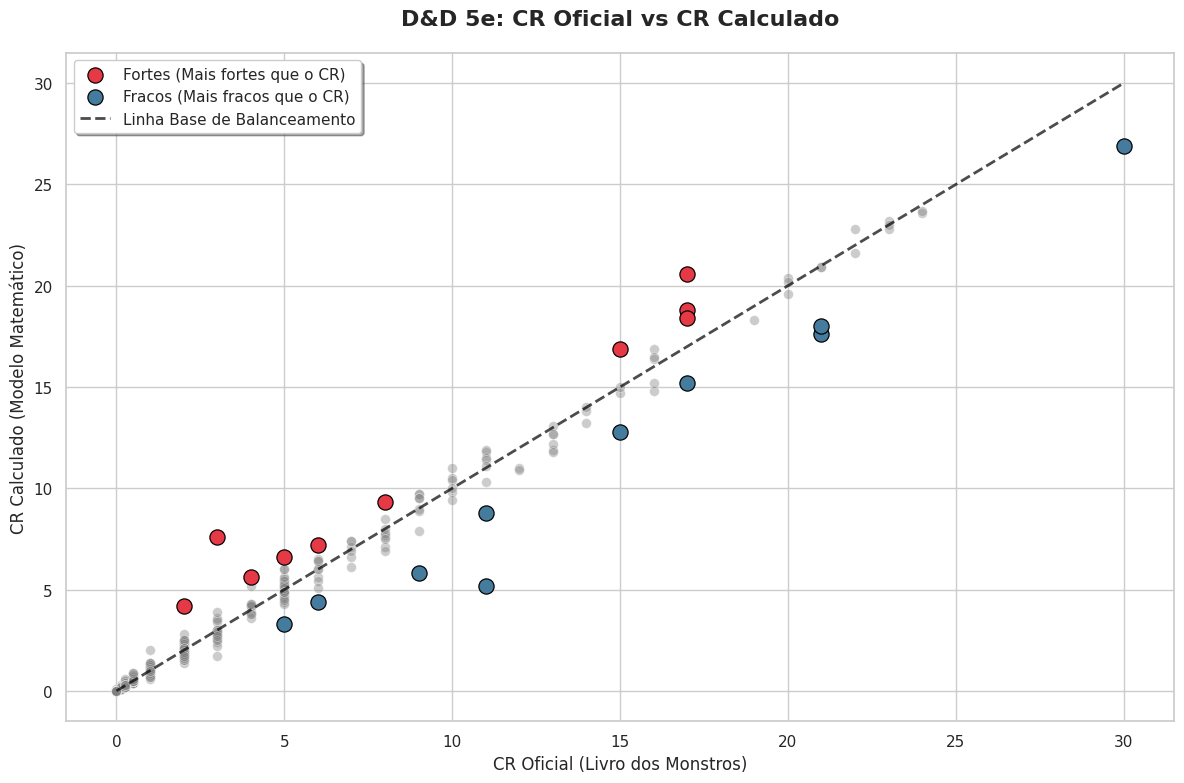

Gráfico salvo em images/strongxweak.png


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configura o estilo visual do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Plota todos os 322 monstros como pontinhos cinzas de fundo
sns.scatterplot(x='cr', y='cr_matematico', data=df, alpha=0.4, color='grey', s=50)

# Destaca os Fortes em vermelho
sns.scatterplot(x='cr', y='cr_matematico', data=assassinos, 
                color='#e63946', s=120, edgecolor='black', label='Fortes (Mais fortes que o CR)')

# Destaca os Fracos em azul
sns.scatterplot(x='cr', y='cr_matematico', data=fracotes, 
                color='#457b9d', s=120, edgecolor='black', label='Fracos (Mais fracos que o CR)')

# Desenha a Linha de Perfeição (onde o CR oficial = CR do modelo)
plt.plot([0, 30], [0, 30], color='black', linestyle='--', linewidth=2, alpha=0.7, label='Linha Base de Balanceamento')

# Personalização de textos e legendas
plt.title('D&D 5e: CR Oficial vs CR Calculado', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('CR Oficial (Livro dos Monstros)', fontsize=12)
plt.ylabel('CR Calculado (Modelo Matemático)', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('../images/strongxweak.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo em images/strongxweak.png")

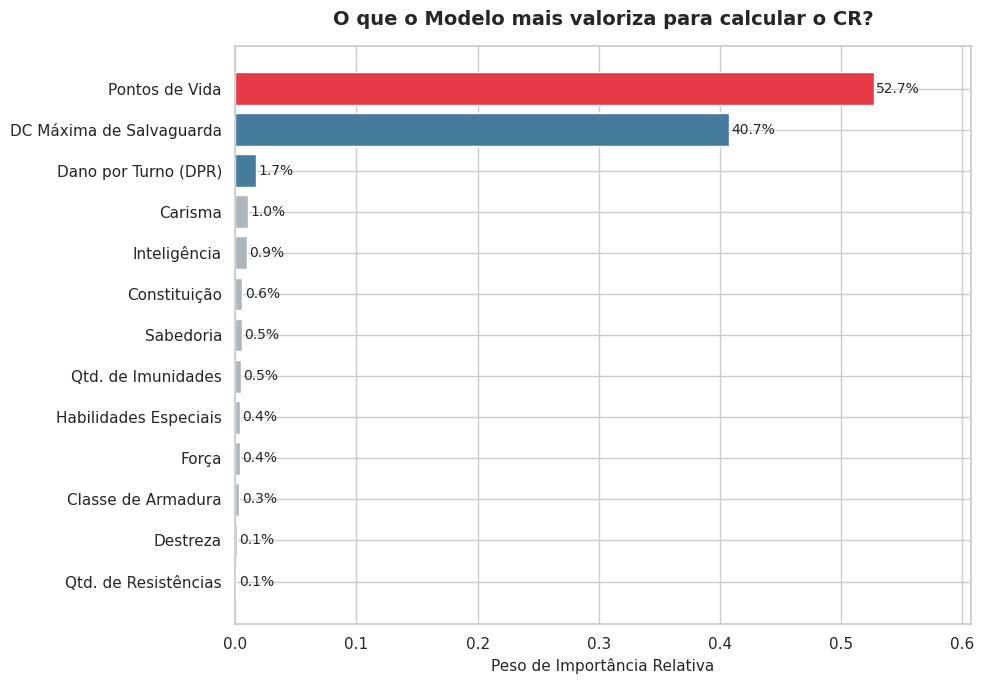

Gráfico salvo em images/feature_importance.png


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Extrai importância de cada feature do modelo treinado
importancias = modelo.feature_importances_
nomes_features = X.columns.tolist()

# Ordena do maior para o menor
indices = np.argsort(importancias)[::-1]
importancias_ordenadas = importancias[indices]
nomes_ordenados = [nomes_features[i] for i in indices]

# Nomes em português para o gráfico
traducao = {
    'armor_class': 'Classe de Armadura',
    'hit_points': 'Pontos de Vida',
    'dpr_maximo': 'Dano por Turno (DPR)',
    'strength': 'Força',
    'dexterity': 'Destreza',
    'constitution': 'Constituição',
    'intelligence': 'Inteligência',
    'wisdom': 'Sabedoria',
    'charisma': 'Carisma',
    'save_dc_max': 'DC Máxima de Salvaguarda',
    'qtd_imunidades': 'Qtd. de Imunidades',
    'qtd_resistencias': 'Qtd. de Resistências',
    'qtd_habilidades_especiais': 'Habilidades Especiais'
}
nomes_pt = [traducao.get(n, n) for n in nomes_ordenados]

plt.figure(figsize=(10, 7))
cores = ['#e63946' if i == 0 else '#457b9d' if i < 3 else '#adb5bd' for i in range(len(nomes_pt))]
bars = plt.barh(nomes_pt[::-1], importancias_ordenadas[::-1], color=cores[::-1])

for bar, val in zip(bars, importancias_ordenadas[::-1]):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=10)

plt.title('O que o Modelo mais valoriza para calcular o CR?', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Peso de Importância Relativa', fontsize=11)
plt.xlim(0, max(importancias) + 0.08)
plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo em images/feature_importance.png")

In [5]:
# Salva o ranking completo de todos os monstros
df.sort_values(by='discrepancia', ascending=False)[
    ['name', 'cr', 'cr_matematico', 'discrepancia', 'hit_points', 'dpr_maximo']
].to_csv('../data/processed/ranking_completo.csv', index=False)

print(f"Ranking completo salvo com {len(df)} monstros em data/processed/ranking_completo.csv")

Ranking completo salvo com 322 monstros em data/processed/ranking_completo.csv
